# Store Sales - Time Series Forecasting

Kaggle competition (https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data) predicting sales for Favorita stores in Ecuador. Contains completed exercises from Kaggle's Time Series course.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

# set matplotlib defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('figure', autolayout=True, figsize=(11, 4))
plt.rc('axes',
       labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=14, titlepad=10)
plot_params = dict(color='0.75', style='.-',
                   markeredgecolor='0.25', markerfacecolor='0.25',
                   legend=False)
%config InlineBackend.figure_format = 'retina'

dtype = {'store_nbr': 'category',
         'family': 'category',
         'sales': 'float32',
         'onpromotion': 'uint64'}

# load training data
store_sales = pd.read_csv('data/train.csv', dtype=dtype, parse_dates=['date'])
store_sales.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [2]:
# set index to Period Index
store_sales = store_sales.set_index('date').to_period('D')
store_sales.head()

,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,0,1,AUTOMOTIVE,0.0,0
2013-01-01,1,1,BABY CARE,0.0,0
2013-01-01,2,1,BEAUTY,0.0,0
2013-01-01,3,1,BEVERAGES,0.0,0
2013-01-01,4,1,BOOKS,0.0,0


In [3]:
# create sub-indices based on store and product family
store_sales = store_sales.set_index(['store_nbr', 'family'], append=True)
store_sales.head()

id  sales  onpromotion
date       store_nbr family                            
2013-01-01 1         AUTOMOTIVE   0    0.0            0
                     BABY CARE    1    0.0            0
                     BEAUTY       2    0.0            0
                     BEVERAGES    3    0.0            0
                     BOOKS        4    0.0            0

In [4]:
# find the average sales for a given date across all stores
average_sales = store_sales.groupby('date').mean()['sales']

## Create linear regression model with a time-step feature

Text(0.5, 1.0, 'Time Plot of Total Store Sales')

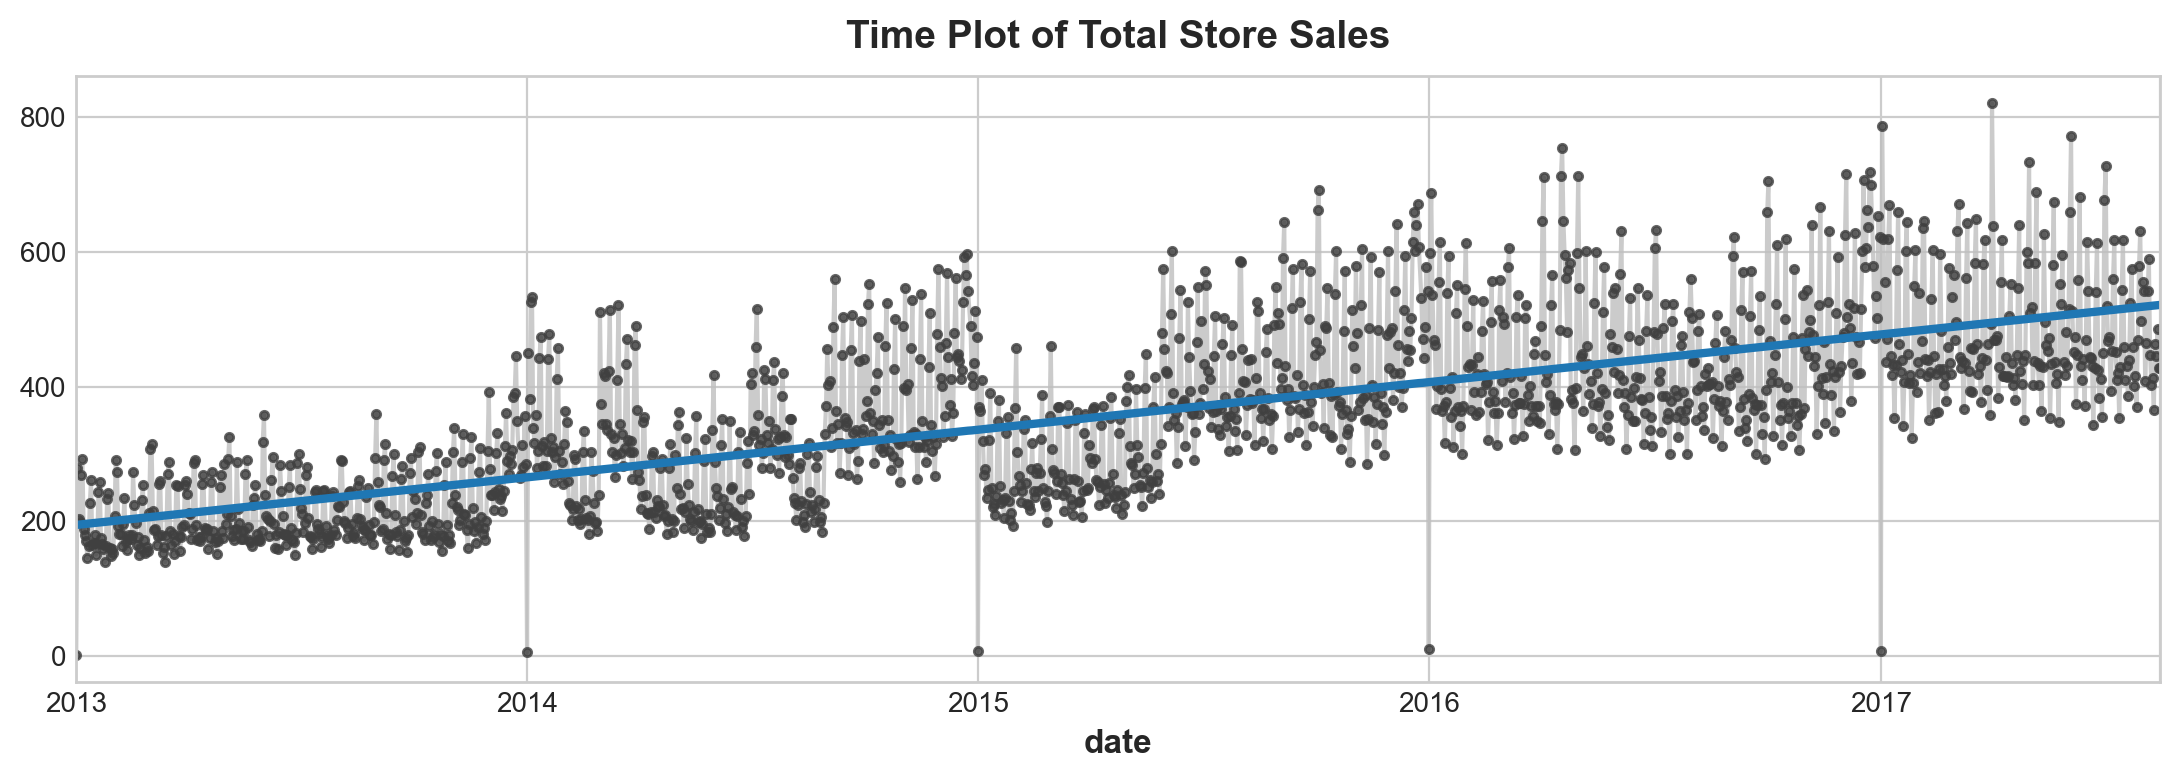

In [5]:
from sklearn.linear_model import LinearRegression

df = average_sales.to_frame()

# create a time dummy
time = np.arange(len(df.index))
df['time'] = time

# organize training data
X = df.loc[:, ['time']] # features; type = DataFrame
y = df.loc[:, 'sales'] # target; type = Series

# train linear regression model
model = LinearRegression()
model.fit(X, y)

# index predicted values with the same time index as training data
y_pred = pd.Series(model.predict(X), index=X.index)

# plot store sales
ax = y.plot(**plot_params, alpha=0.8)
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title('Time Plot of Total Store Sales')

## Create linear regression model with a lag feature

In [6]:
# create 1-day shift lag feature & add to dataframe
lag_1 = df['sales'].shift(1)
df['lag_1'] = lag_1

X = df.loc[:, ['lag_1']].dropna() # features; drop null
y = df.loc[:, 'sales'] # target
y, X = y.align(X, join='inner') # drop the corresponding values in target (works since they have the same indexing)

# train linear regression model
model = LinearRegression()
model.fit(X, y)

# index predicted values with the same time index as training data
y_pred = pd.Series(model.predict(X), index=X.index)

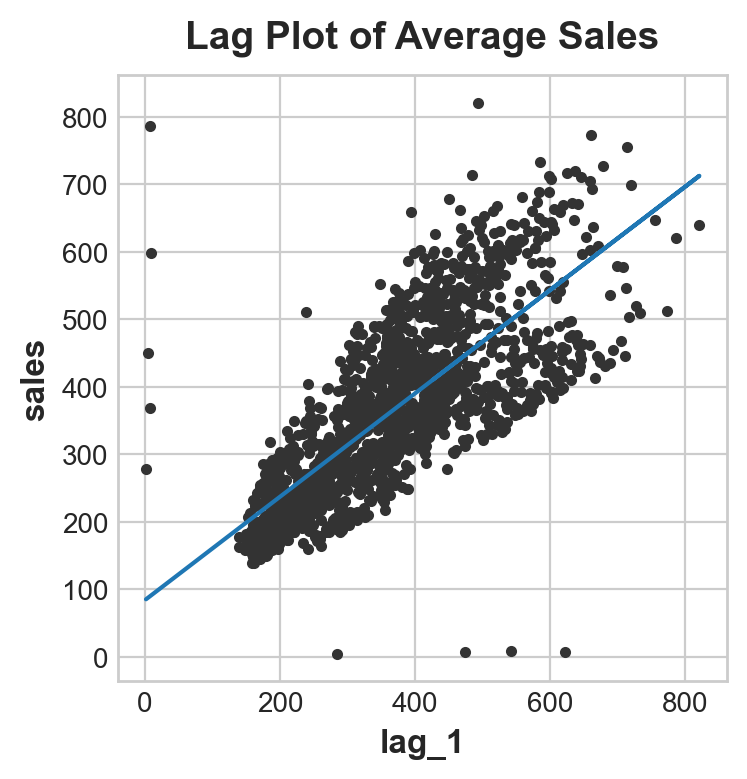

In [7]:
fig, ax = plt.subplots()
ax.plot(X['lag_1'], y, '.', color='0.2')
ax.plot(X['lag_1'], y_pred)
ax.set(aspect='equal', ylabel='sales', xlabel='lag_1', title='Lag Plot of Average Sales');

## Create trend feature

Plot the rolling average to get an idea of what kind of trend model could represent the data.

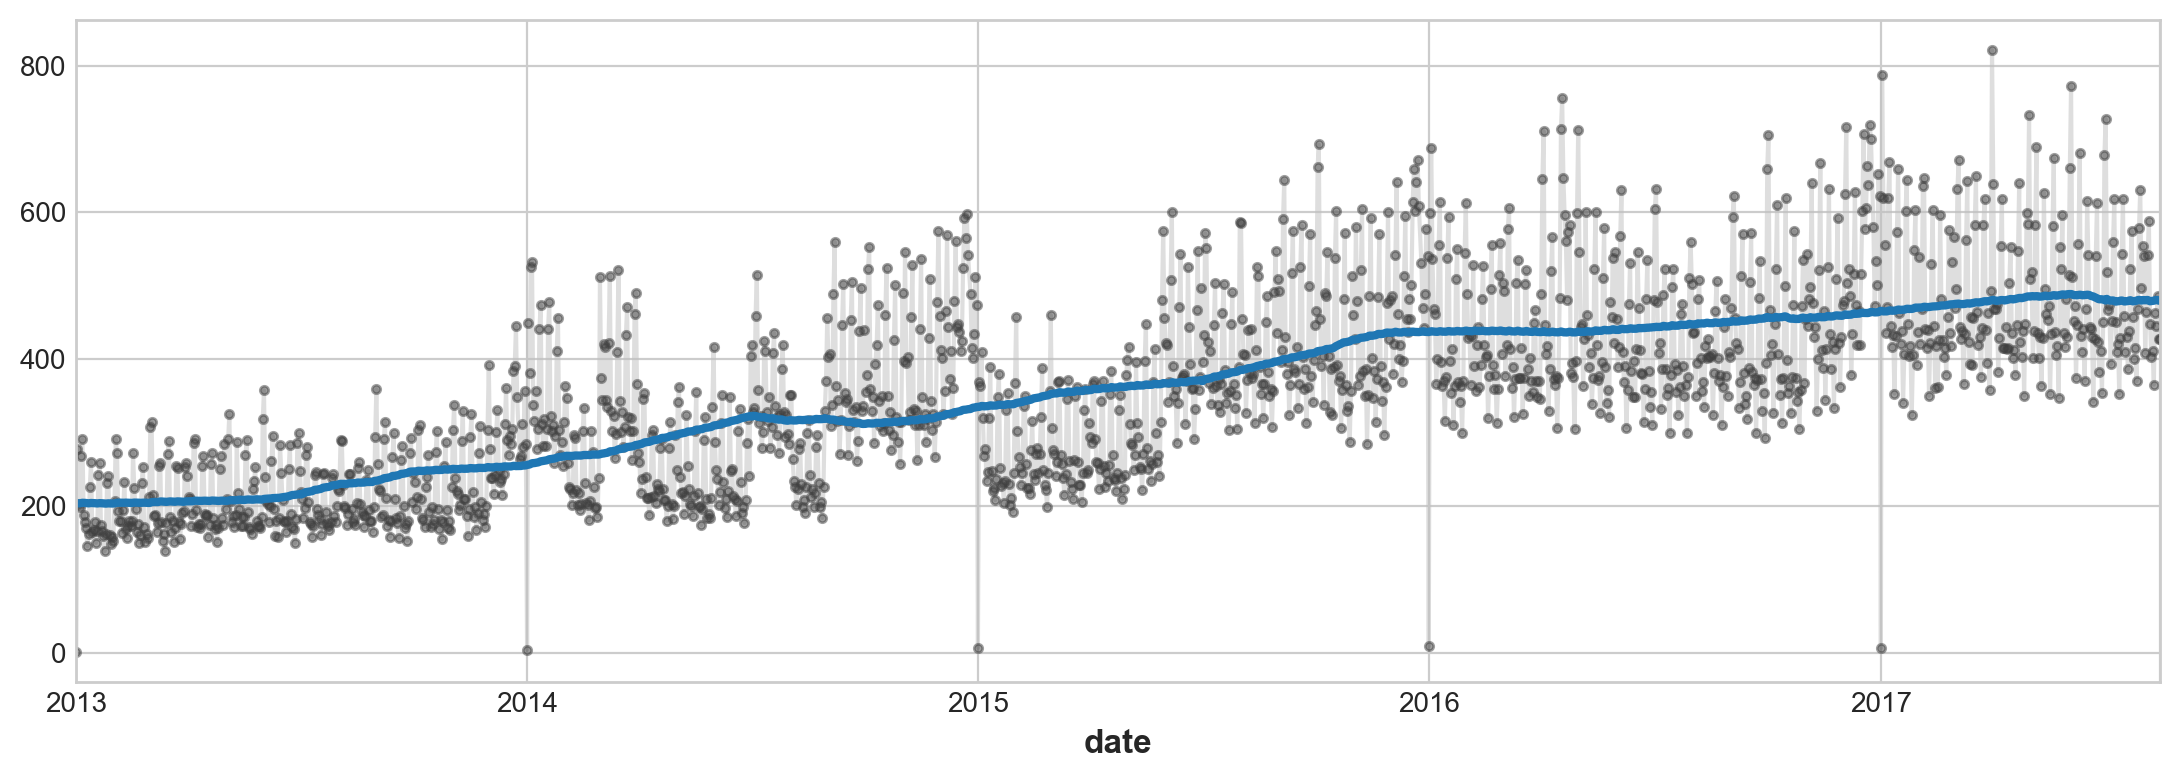

In [8]:
trend = average_sales.rolling(window=365, # 365-day averaging window
                              center=True, # use centre of window
                              min_periods=183, # minimum 183 days for window
                             ).mean()

ax = average_sales.plot(**plot_params, alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)

In [9]:
from statsmodels.tsa.deterministic import DeterministicProcess

y = average_sales.copy() # target

dp = DeterministicProcess(index=y.index,
                          order=3, # cubic order model
                          drop=True, # drop linearly-dependent terms
                         )

X = dp.in_sample() # features for dates given in index
X.head()

,trend,trend_squared,trend_cubed
date,,,
2013-01-01,1.0,1.0,1.0
2013-01-02,2.0,4.0,8.0
2013-01-03,3.0,9.0,27.0
2013-01-04,4.0,16.0,64.0
2013-01-05,5.0,25.0,125.0


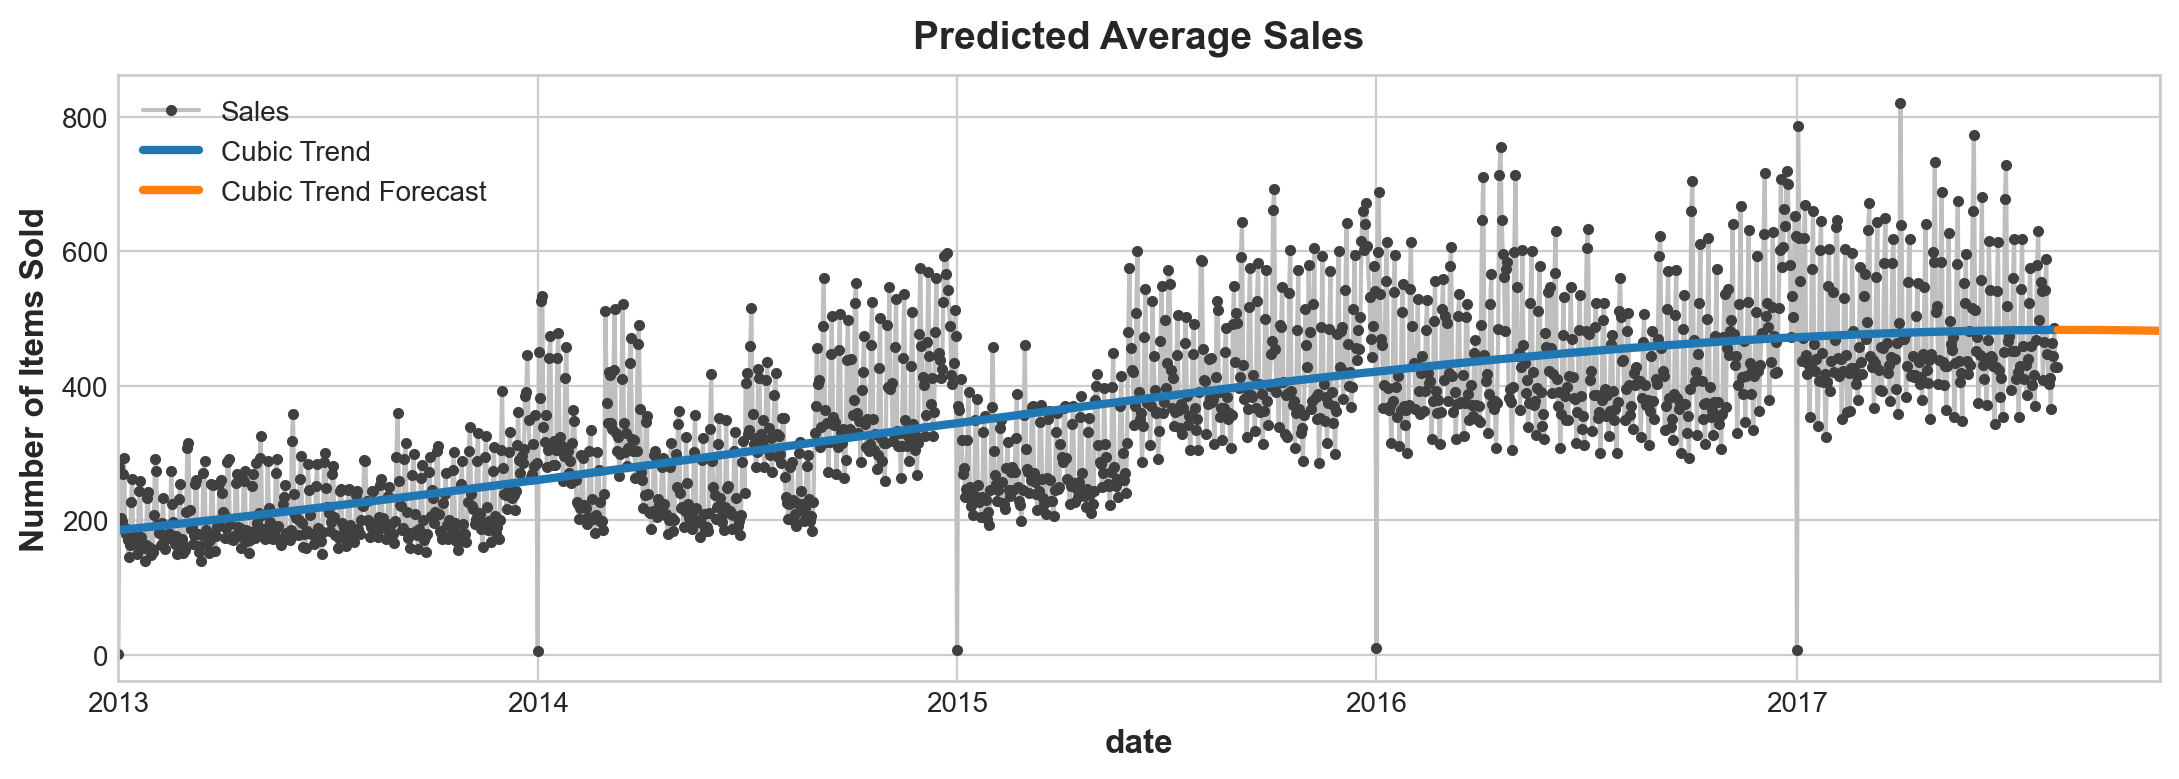

In [10]:
# 90-day forecast:
X_fore = dp.out_of_sample(steps=90)

model = LinearRegression()
model.fit(X,y)

y_pred = pd.Series(model.predict(X), index=X.index)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(**plot_params, title='Predicted Average Sales', 
            xlabel='Year', ylabel='Number of Items Sold', label='Sales')
ax = y_pred.plot(ax=ax, linewidth=3, label='Cubic Trend')
ax = y_fore.plot(ax=ax, linewidth=3, label='Cubic Trend Forecast')
ax.legend();

Note that higher-order polynomials tend to overfit the data and are not reliable for out-of-sample forecasting because they can diverge rapidly. See below for 11-th order example.

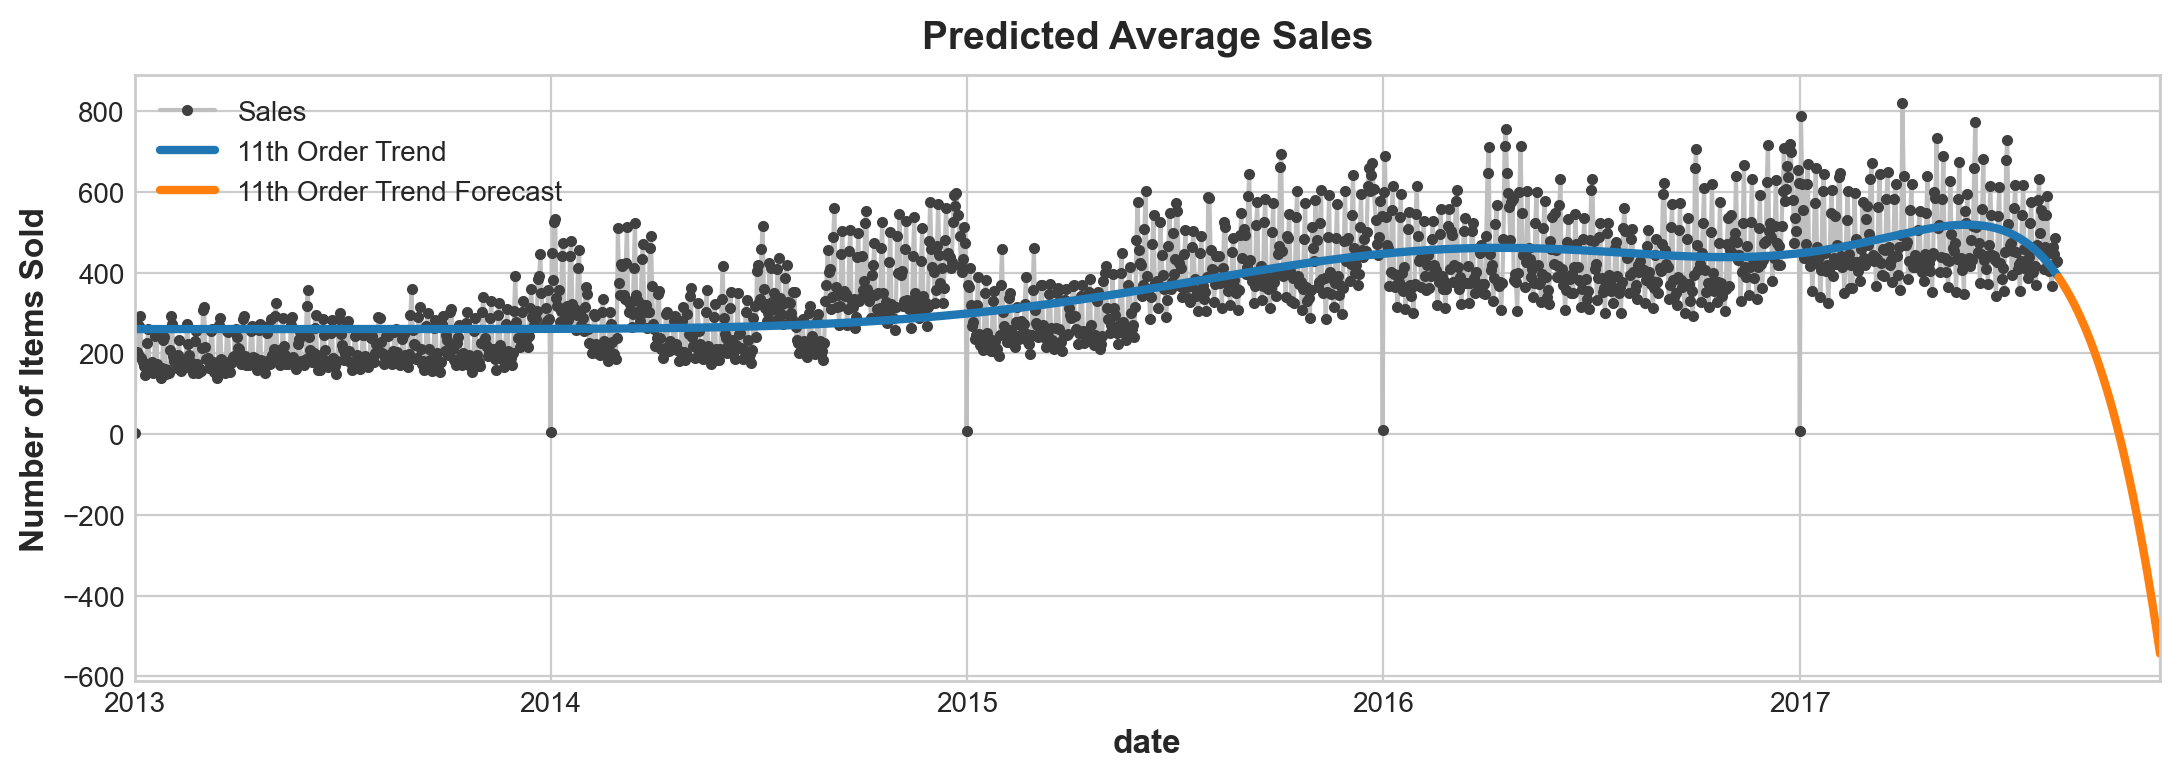

In [11]:
y = average_sales.copy() # target

dp = DeterministicProcess(index=y.index,
                          order=11, # tenth-order model
                         )

X = dp.in_sample() # features for dates given in index
model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)
X_fore = dp.out_of_sample(steps=90)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(**plot_params, title='Predicted Average Sales', 
            xlabel='Year', ylabel='Number of Items Sold', label='Sales')
ax = y_pred.plot(ax=ax, linewidth=3, label='11th Order Trend')
ax = y_fore.plot(ax=ax, linewidth=3, label='11th Order Trend Forecast')
ax.legend();

## Examine seasonality

In [12]:
# re-import data to include more columns
store_sales = pd.read_csv('data/train.csv',
    usecols=['store_nbr', 'family', 'date', 'sales'],
    dtype={'store_nbr': 'category', 'family': 'category', 'sales': 'float32',},
    parse_dates=['date'],
)

store_sales['date'] = store_sales.date.dt.to_period('D')
store_sales = store_sales.set_index(['store_nbr', 'family', 'date']).sort_index()
average_sales = (store_sales
    .groupby('date').mean()
    .squeeze()
    .loc['2017']
)

In [13]:
# from 'Seasonality' in 'Time Series' on Kaggle

def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette('husl', n_colors=X[period].nunique(),)
    ax = sns.lineplot(x=freq, y=y,
                      hue=period,
                      data=X,
                      errorbar=('ci', False),
                      ax=ax,
                      palette=palette,
                      legend=False)
    ax.set_title(f'Seasonal Plot ({period}/{freq})')
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(name,
                    xy=(1,y_),
                    xytext=(6,0),
                    # color=line.getcolor(),
                    xycoords=ax.get_yaxis_transform(),
                    textcoords='offset points',
                    size=14,
                    va='center',)
    return ax
                    
def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta('365D') / pd.Timedelta('1D')
    frequencies, spectrum = periodogram(ts, fs=fs, detrend=detrend, window='boxcar', scaling='spectrum')
    if ax is None:
        _, ax = plt.subplots()
        ax.step(frequencies, spectrum, color='purple')
        ax.set_xscale('log')
        ax.set_xticks([1,2,4,6,12,26,52,104])
        ax.set_xticklabels(['Annual (1)', 'Semiannual (2)', 'Quarterly (4)', 'Bimonthly (6)',
                            'Monthly (12)', 'Biweekly (26)', 'Weekly (52)', 'Semiweekly (104)',],
                           rotation=30,)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        ax.set_ylabel('Variance')
        ax.set_title('Periodogram')
        return ax

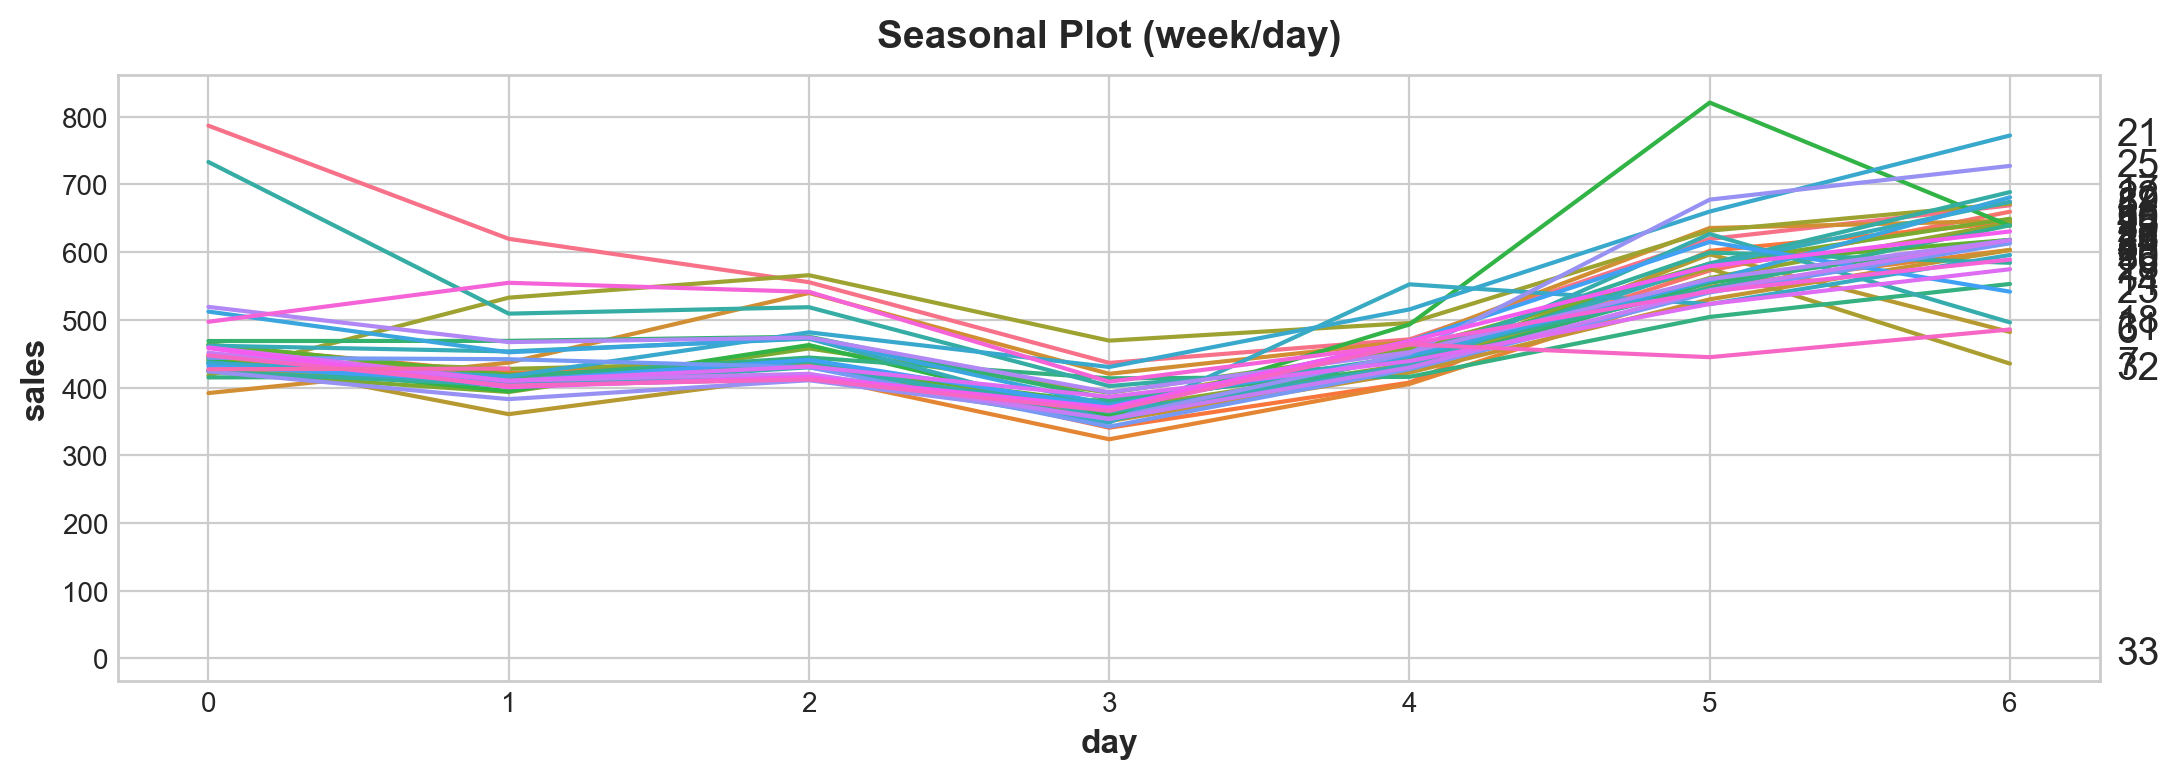

In [14]:
X = average_sales.to_frame()
X['week'], X['day'] = X.index.week, X.index.dayofweek
seasonal_plot(X, y='sales', period='week', freq='day');

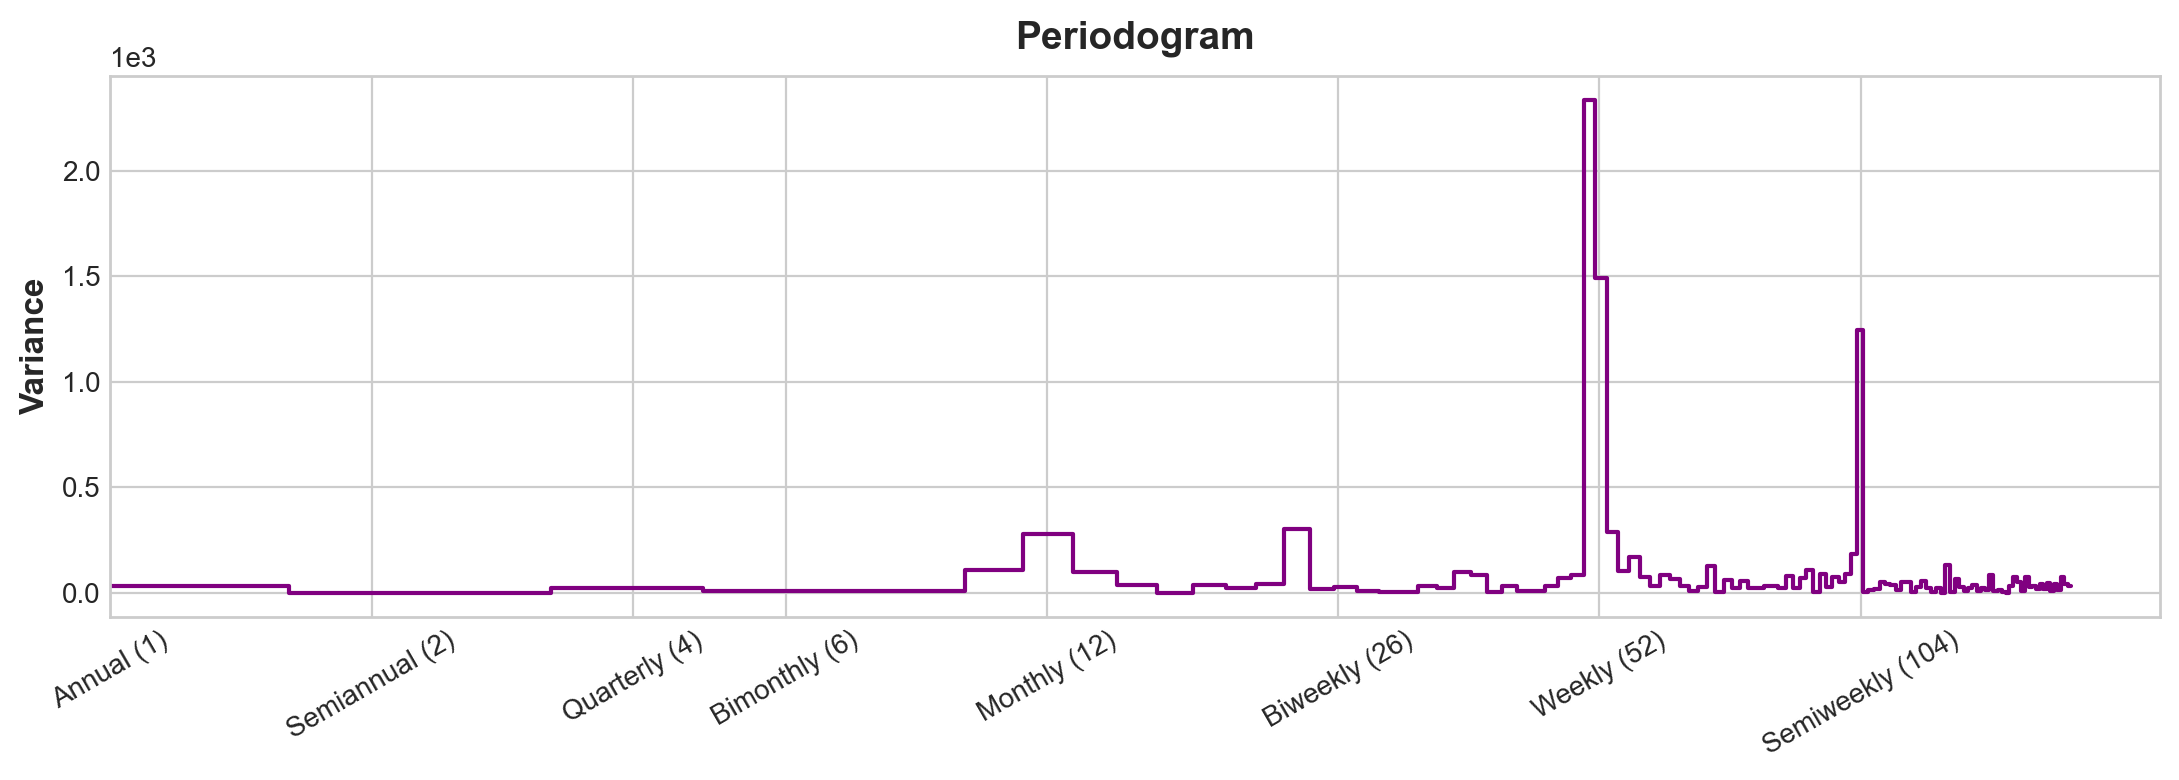

In [15]:
plot_periodogram(average_sales);

From the periodogram we clearly see weekly seasonality, and to a lesser extent monthly.

Now we want to create seasonal features using:
- seasonal indicators for weekly
- Fourier features for monthly

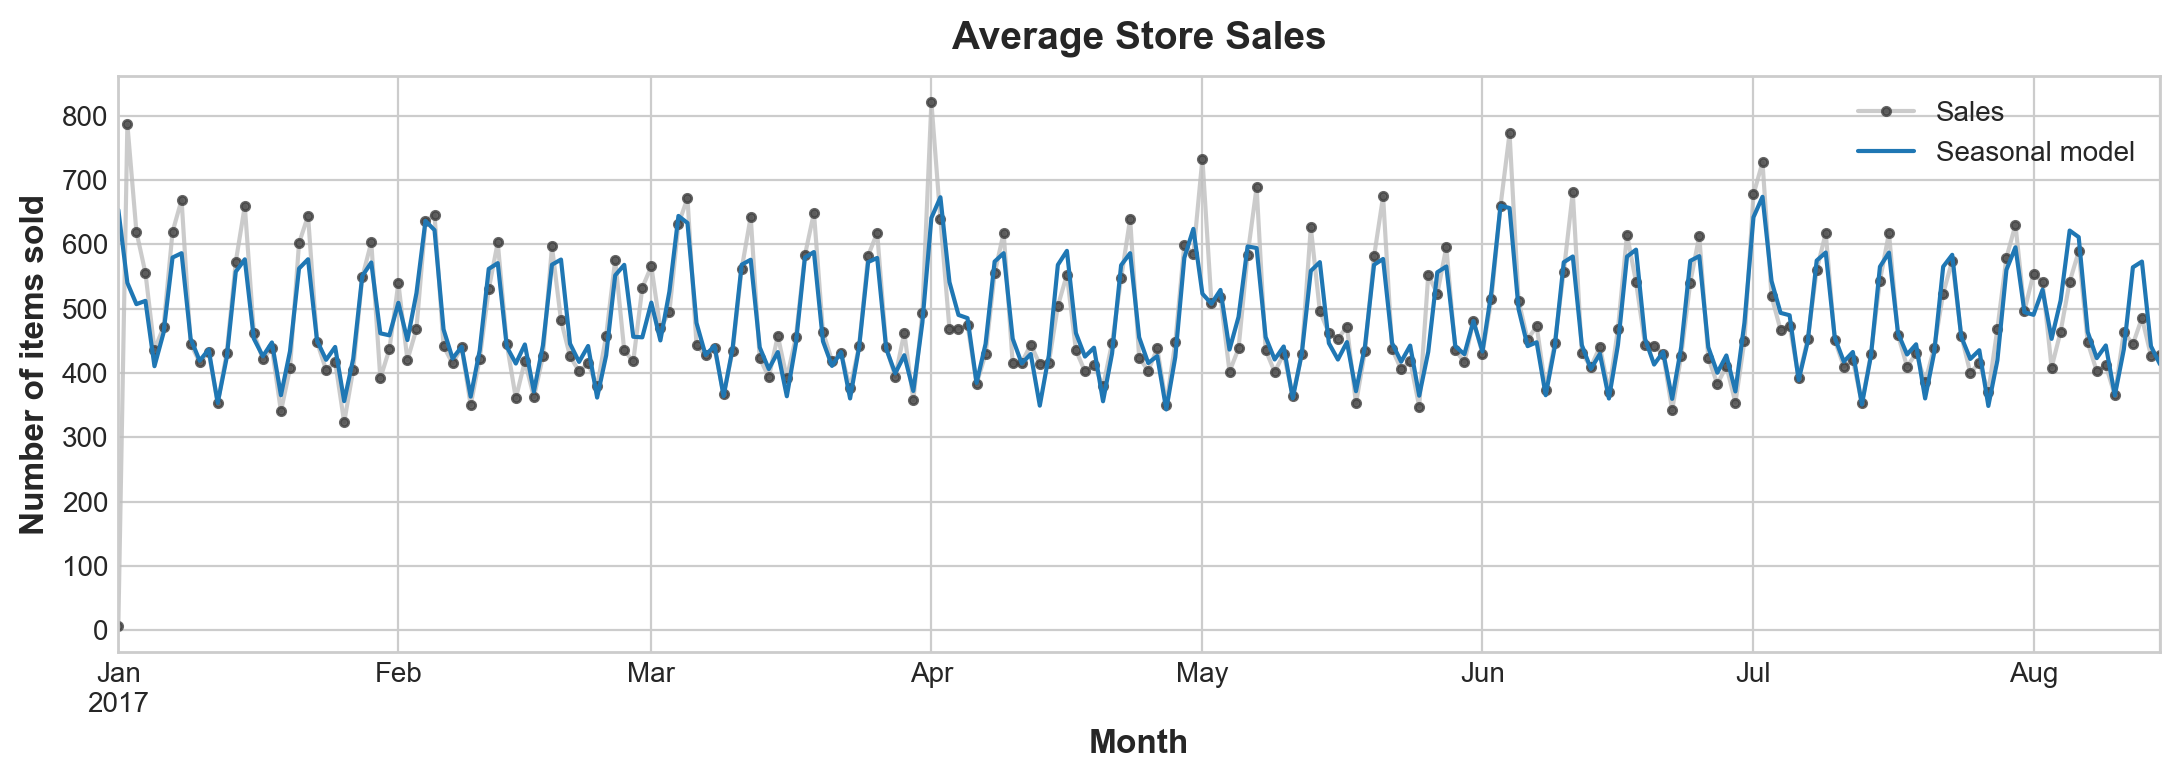

In [16]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

y = average_sales.copy()

fourier = CalendarFourier(freq='ME', order=4) # monthly seasonality with 4 Fourier pairs of increasing frequency
dp = DeterministicProcess(index=y.index,
                          constant=True, # include bias (y-intercept)
                          order=1, # linear order
                          seasonal=True, # seasonal indicators for weekly seasonality
                          additional_terms=[fourier],
                          drop=True, # drop collinear terms
                         )
X = dp.in_sample() # create features for average_sales dates

model = LinearRegression().fit(X,y)
y_pred = pd.Series(model.predict(X), index=X.index)

ax = y.plot(**plot_params, alpha=0.8, title='Average Store Sales', ylabel='Number of items sold', label='Sales')
ax = y_pred.plot(ax=ax, label='Seasonal model')
ax.set_xlabel('Month')
ax.legend();

Check how well our model did by **deseasoning** the series and looking at the resulting periodogram.

In [17]:
y_deseason = y - y_pred

# fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(10, 8))
# ax1 = plot_periodogram(y, ax=ax1)
# ax1.set_title('Product Sales Frequency Components')
# ax2 = plot_periodogram(y_deseason, ax=ax2);
# ax2.set_title('Deseasonalized');

## Create holiday features

We would expect holidays to have an effect on store sales.

In [18]:
holidays_events = pd.read_csv('data/holidays_events.csv',
                              dtype={'type': 'category', 'locale': 'category',
                                     'locale_name': 'category', 'description': 'category',
                                     'transferred': 'bool',},
                              parse_dates=['date'])

holidays_events.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [19]:
holidays_events = holidays_events.set_index('date').to_period('D')
holidays_events.head()

,type,locale,locale_name,description,transferred
date,,,,,
2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [20]:
holidays = (holidays_events.query('locale in ["National", "Regional"]')
            .loc['2017': '2017-08-15', ['description']]
            .assign(description=lambda x: x.description.cat.remove_unused_categories()))
display(holidays)

,description
date,
2017-01-01,Primer dia del ano
2017-01-02,Traslado Primer dia del ano
2017-02-27,Carnaval
2017-02-28,Carnaval
2017-04-01,Provincializacion de Cotopaxi
2017-04-14,Viernes Santo
2017-05-01,Dia del Trabajo
2017-05-13,Dia de la Madre-1
2017-05-14,Dia de la Madre


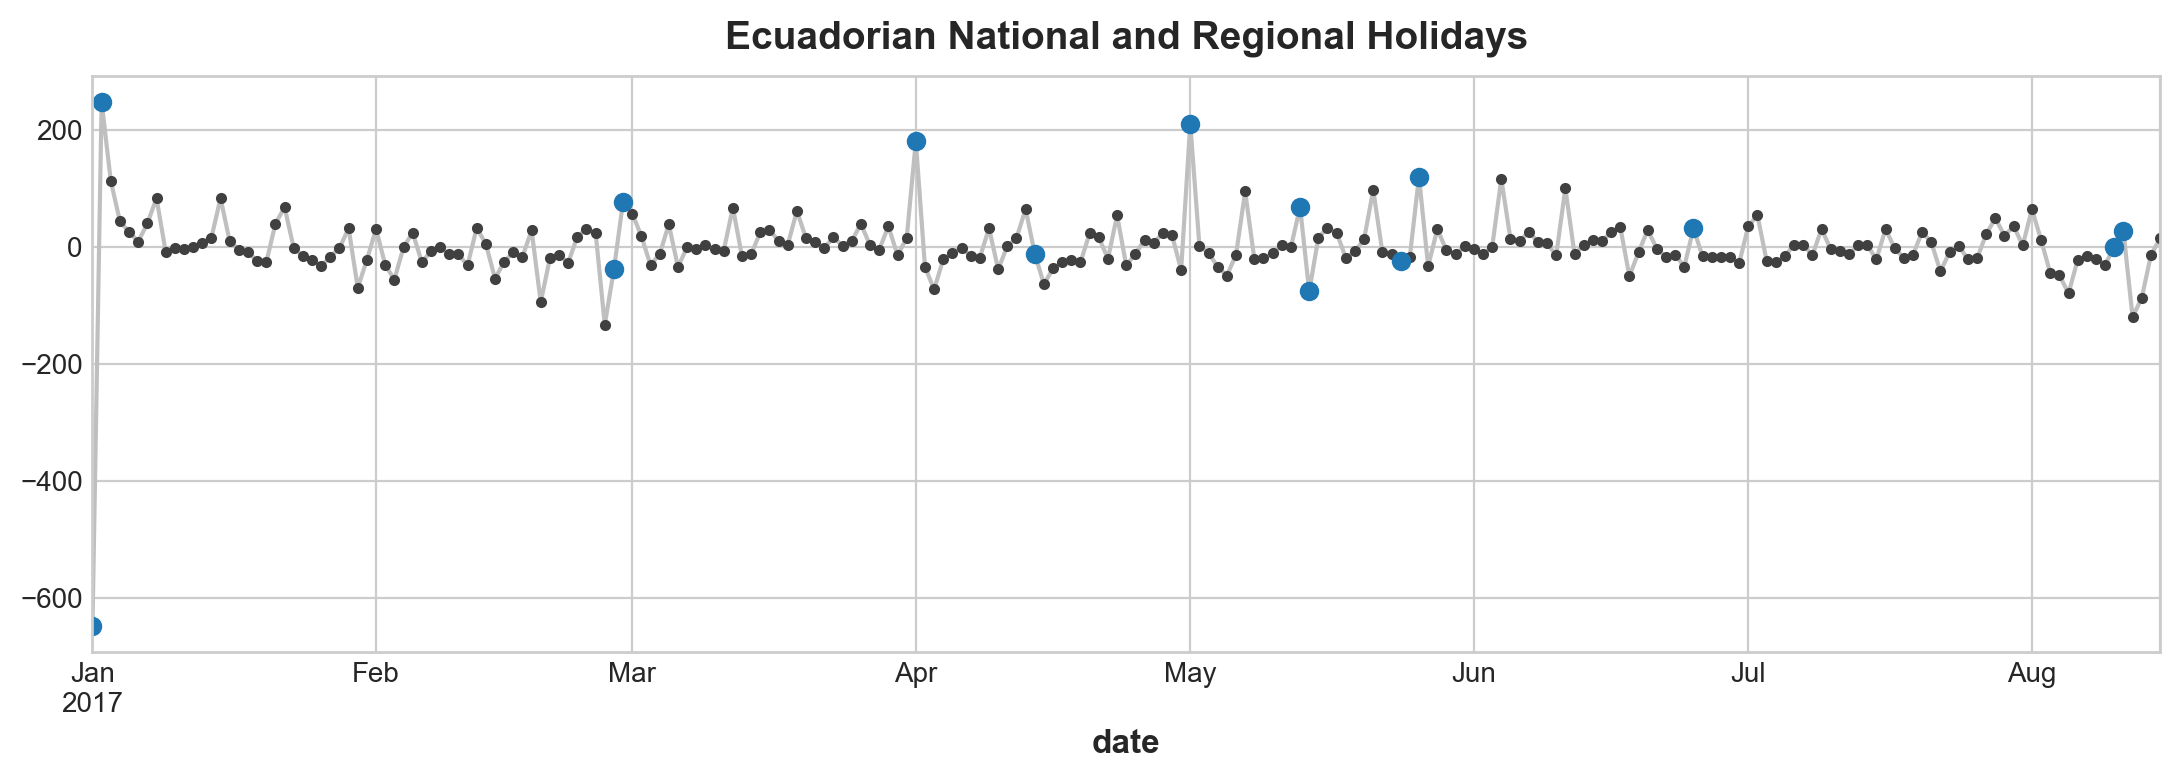

In [21]:
ax = y_deseason.plot(**plot_params)
plt.plot(holidays.index, y_deseason[holidays.index],  linestyle='none', marker='o')
ax.set_title('Ecuadorian National and Regional Holidays');

In [22]:
X_holidays = pd.get_dummies(holidays) # converts categorical variable into dummy/indicator variables

X2 = X.join(X_holidays, on='date').fillna(0.0)

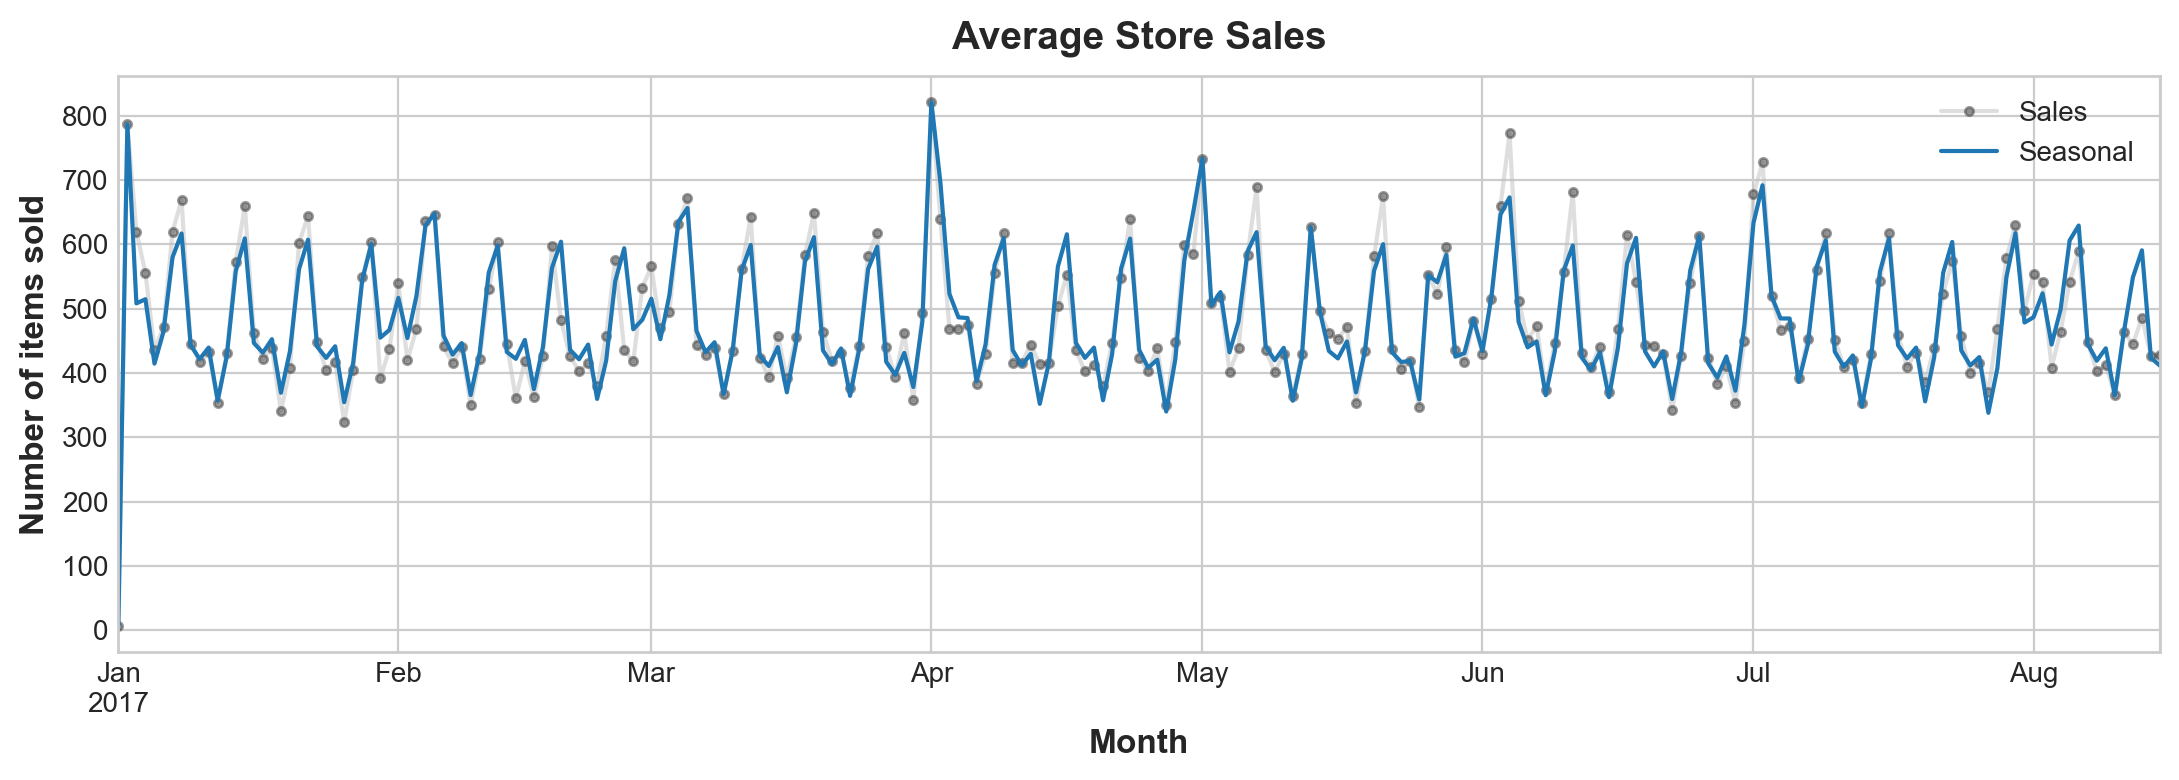

In [23]:
model = LinearRegression().fit(X2, y)
y_pred = pd.Series(
    model.predict(X2),
    index=X2.index,
    name='Fitted',
)

y_pred = pd.Series(model.predict(X2), index=X2.index)
ax = y.plot(**plot_params, alpha=0.5, title='Average Store Sales', ylabel='Number of items sold', label='Sales')
ax = y_pred.plot(ax=ax, label='Seasonal')
ax.set_xlabel('Month')
ax.legend();